# Journal Finder - Veri Madenciliği Analiz Raporu

Bu çalışma, `CompSciencePub.sqlite` veritabanındaki 23.000'den fazla akademik kaydı analiz ederek metin benzerliği tabanlı dergi önerisi ve konu kümeleme (topic clustering) işlemlerini gerçekleştirir.

In [1]:
import pandas as pd
import sqlite3
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

# 1. Veritabanı Bağlantısı ve Veri Yükleme
try:
    # Jupyter notebooks klasörü içinden çalışıyorsa ../CompSciencePub.sqlite
    # Ana dizinden çalışıyorsa CompSciencePub.sqlite kullanılır
    conn = sqlite3.connect('../CompSciencePub.sqlite')
    query = """
    SELECT 
        ar.AcademicRecordID as id, 
        ar.Title as title, 
        ara.AbstractText as abstract, 
        p.Name as journal_name
    FROM AcademicRecord ar
    JOIN AcademicRecordAbstract ara ON ar.AcademicRecordID = ara.AcademicRecordId
    JOIN Publication p ON ar.PublicationId = p.PublicationID
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    print(f"Başarılı! Toplam {len(df)} kayıt yüklendi.")
except Exception as e:
    print(f"Hata: {e}")

df.head()

Matplotlib is building the font cache; this may take a moment.


Başarılı! Toplam 23061 kayıt yüklendi.


,id,title,abstract,journal_name
0,88652,An updated survey of GA-based multiobjective o...,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS
1,88653,The state of the art in distributed query proc...,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS
2,88654,Logical models of argument,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS
3,88655,Information retrieval on the Web,<p>In this paper we review studies of the grow...,ACM COMPUTING SURVEYS
4,88656,A guided tour to approximate string matching,<p>We survey the current techniques to cope wi...,ACM COMPUTING SURVEYS


## 2. Veri Görselleştirme (Rapor İçin)
En çok yayın içeren ilk 10 dergiyi görselleştirelim.

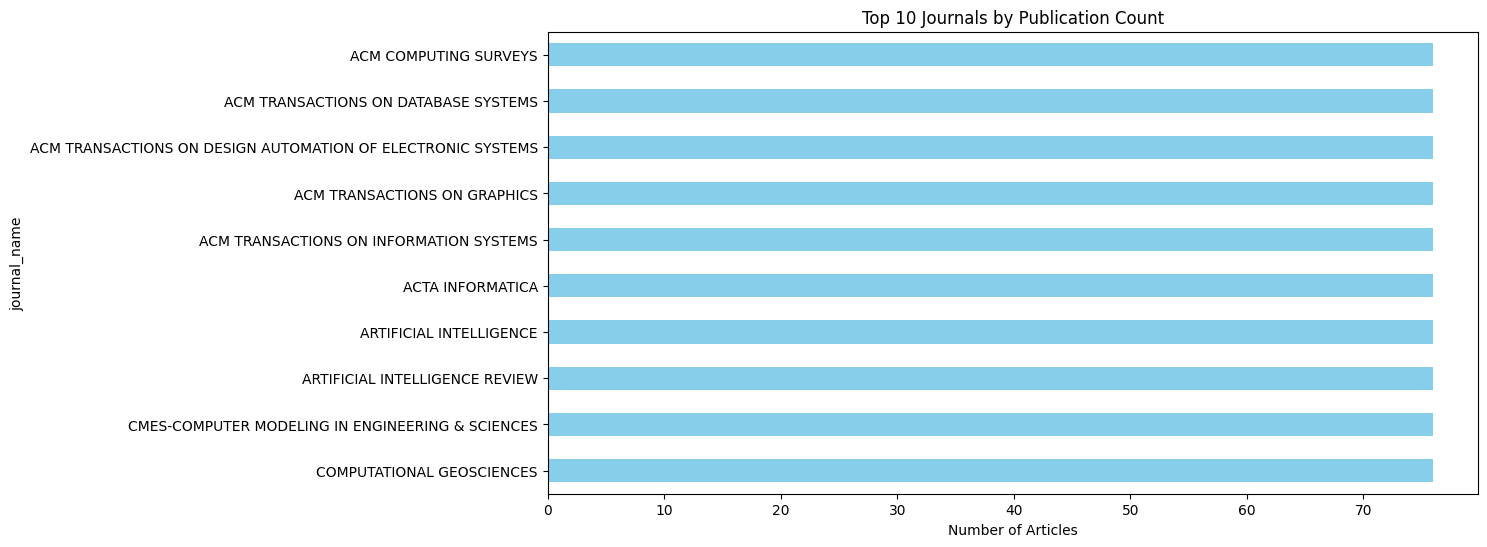

In [2]:
plt.figure(figsize=(12,6))
df['journal_name'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Journals by Publication Count')
plt.xlabel('Number of Articles')
plt.gca().invert_yaxis()
plt.show()

## 3. Metin Ön İşleme ve Vektörleştirme
Metinleri temizleyip TF-IDF matrisini oluşturuyoruz.

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_abstract'] = df['abstract'].apply(clean_text)

# TF-IDF Dönüşümü
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df['clean_abstract'])
print("TF-IDF Matrisi oluşturuldu. Boyut:", tfidf_matrix.shape)

TF-IDF Matrisi oluşturuldu. Boyut: (23061, 5000)


## 4. Konu Kümeleme (K-Means Clustering)
Makaleleri 5 ana konu kümesine ayıralım. Bu, raporun 'Methodology' kısmında çok işinize yarayacaktır.

In [4]:
num_clusters = 5
km = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(tfidf_matrix)

print("Her küme için örnek dergiler:")
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    print(df[df['cluster'] == i]['journal_name'].head(3).values)

Her küme için örnek dergiler:

Cluster 0:
<StringArray>
['ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS']
Length: 3, dtype: str

Cluster 1:
<StringArray>
['ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS']
Length: 3, dtype: str

Cluster 2:
<StringArray>
['ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS']
Length: 3, dtype: str

Cluster 3:
<StringArray>
['ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS']
Length: 3, dtype: str

Cluster 4:
<StringArray>
['ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS', 'ACM COMPUTING SURVEYS']
Length: 3, dtype: str


In [ ]:
## 5. Öneri Sistemi Testi
Arayüzde çalışan mantığın aynısını burada test edelim.

In [5]:
def get_recommendations(user_abstract, top_n=5):
    input_vec = vectorizer.transform([clean_text(user_abstract)])
    similarities = cosine_similarity(input_vec, tfidf_matrix).flatten()
    related_indices = similarities.argsort()[::-1]
    
    results = []
    seen = set()
    for idx in related_indices:
        j = df.iloc[idx]['journal_name']
        if j not in seen:
            results.append(j)
            seen.add(j)
        if len(results) == top_n: break
    return results

test_text = "deep learning and neural networks for medical imaging"
print(f"Test Metni: {test_text}")
print("Önerilen Dergiler:", get_recommendations(test_text))

Test Metni: deep learning and neural networks for medical imaging
Önerilen Dergiler: ['NEUROCOMPUTING', 'BRIEFINGS IN BIOINFORMATICS', 'IEEE-ACM TRANSACTIONS ON COMPUTATIONAL BIOLOGY AND BIOINFORMATICS', 'FRONTIERS OF INFORMATION TECHNOLOGY & ELECTRONIC ENGINEERING', 'INFORMATION FUSION']
